In [104]:
#f = pd.read_csv('/content/drive/MyDrive/preprocessed_lenta_titles.csv', sep = ",", encoding="utf-8")
text = f['title'].astype(str).tolist()
text = map(str, text)
text = '. '.join(text)

In [105]:
text

'В Курской области объявили опасность атаки БПЛА. Юристы прокомментировали иск пострадавших в отношении владельцев «Крокуса». На Западе рассказали о нехватке Patriot для передачи ВСУ. Очередные российские спортсмены отказались от участия в Олимпиаде-2024. Байден и Си Цзиньпин обсудили ситуацию вокруг TikTok. Последствия мощного землетрясения на Тайване показали на видео. Родственникам погибших в «Крокусе»  назначили более 66 пенсий. Цунами достигло японского острова после землетрясения близ Тайваня. На Украине заявили об ужесточении мобилизации из-за «военных законов». Британия осудила Северную Корею из-за пуска баллистической ракеты. «Ростов» вышел в следующий этап Кубка России. «Локомотив» повел в серии у «Трактора» в полуфинале Кубка Гагарина. Названо число россиян с кредитами. Запад создал план по сохранению поставок оружия Украине при возвращении Трампа. Близ Тайваня зафиксировали еще четыре землетрясения. Диетолог раскрыла неожиданную пользу апельсинов. Украинские миллиардеры ста

In [106]:
type(text)

str

In [107]:
len(text)

4386519

In [108]:
text[:300]

'В Курской области объявили опасность атаки БПЛА. Юристы прокомментировали иск пострадавших в отношении владельцев «Крокуса». На Западе рассказали о нехватке Patriot для передачи ВСУ. Очередные российские спортсмены отказались от участия в Олимпиаде-2024. Байден и Си Цзиньпин обсудили ситуацию вокруг'

**Предварительная обработка текста**


In [109]:
# перевод в единый регистр (например, нижний)
text = text.lower()

In [110]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [111]:
type(string.punctuation)

str

In [112]:
spec_chars = string.punctuation + '\n\xa0«»\t—…'

In [113]:
%%time
text = "".join([ch for ch in text if ch not in spec_chars])

CPU times: user 859 ms, sys: 300 ms, total: 1.16 s
Wall time: 1.18 s


In [114]:
import re
text = re.sub('\n', ' ', text)

In [115]:
def remove_chars_from_text(text, chars):
    return "".join([ch for ch in text if ch not in chars])

In [116]:
%%time
text = remove_chars_from_text(text, spec_chars)

CPU times: user 719 ms, sys: 177 ms, total: 896 ms
Wall time: 898 ms


In [117]:
%%time
text = remove_chars_from_text(text, string.digits)

CPU times: user 539 ms, sys: 176 ms, total: 715 ms
Wall time: 719 ms


In [118]:
text

'в курской области объявили опасность атаки бпла юристы прокомментировали иск пострадавших в отношении владельцев крокуса на западе рассказали о нехватке patriot для передачи всу очередные российские спортсмены отказались от участия в олимпиаде байден и си цзиньпин обсудили ситуацию вокруг tiktok последствия мощного землетрясения на тайване показали на видео родственникам погибших в крокусе  назначили более  пенсий цунами достигло японского острова после землетрясения близ тайваня на украине заявили об ужесточении мобилизации изза военных законов британия осудила северную корею изза пуска баллистической ракеты ростов вышел в следующий этап кубка россии локомотив повел в серии у трактора в полуфинале кубка гагарина названо число россиян с кредитами запад создал план по сохранению поставок оружия украине при возвращении трампа близ тайваня зафиксировали еще четыре землетрясения диетолог раскрыла неожиданную пользу апельсинов украинские миллиардеры стали беднее крупнейший производитель чи

**Токенизация текста**

In [119]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [120]:
from nltk import word_tokenize
text_tokens = word_tokenize(text)

In [121]:
print(type(text_tokens), len(text_tokens))
text_tokens[:10]

<class 'list'> 587552


['в',
 'курской',
 'области',
 'объявили',
 'опасность',
 'атаки',
 'бпла',
 'юристы',
 'прокомментировали',
 'иск']

In [122]:
import nltk
text = nltk.Text(text_tokens)
print(type(text))
text[:10]

<class 'nltk.text.Text'>


['в',
 'курской',
 'области',
 'объявили',
 'опасность',
 'атаки',
 'бпла',
 'юристы',
 'прокомментировали',
 'иск']

**Расчёт растоты встречаемости слов**

In [123]:
%%time
from nltk.probability import FreqDist
fdist = FreqDist(text)
fdist

CPU times: user 529 ms, sys: 1.78 ms, total: 531 ms
Wall time: 535 ms


FreqDist({'в': 37186, 'на': 16969, 'о': 12152, 'с': 8239, 'россии': 8183, 'и': 7777, 'по': 4377, 'сша': 4108, 'украине': 3785, 'за': 3781, ...})

In [124]:
fdist.most_common(5)

[('в', 37186), ('на', 16969), ('о', 12152), ('с', 8239), ('россии', 8183)]

<Axes: xlabel='Samples', ylabel='Counts'>

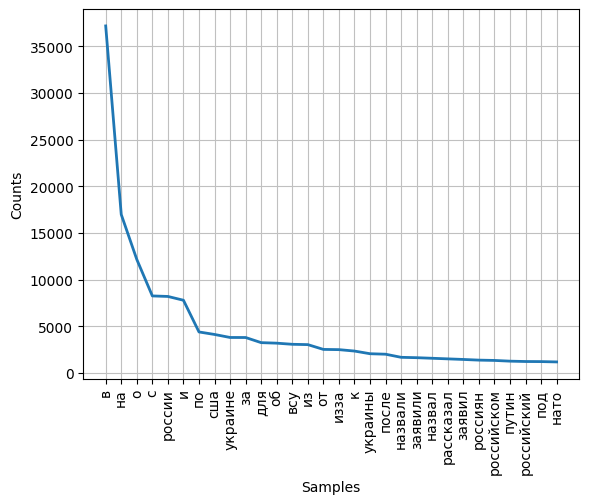

In [125]:
fdist.plot(30,cumulative=False)

**Удаление стоп-слов**

In [126]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [127]:
from nltk.corpus import stopwords
russian_stopwords = stopwords.words("russian")
#russian_stopwords.extend(['это', 'нею'])

In [128]:
print(len(russian_stopwords))
# russian_stopwords

151


In [129]:
%%time
text_tokens = [token.strip() for token in text_tokens if token not in russian_stopwords]

CPU times: user 1.16 s, sys: 6.04 ms, total: 1.17 s
Wall time: 1.17 s


In [130]:
print(len(text_tokens))

465519


In [131]:
text = nltk.Text(text_tokens)

In [132]:
fdist_sw = FreqDist(text)
fdist_sw.most_common(10)

[('россии', 8183),
 ('сша', 4108),
 ('украине', 3785),
 ('всу', 3054),
 ('изза', 2481),
 ('украины', 2043),
 ('назвали', 1658),
 ('заявили', 1618),
 ('назвал', 1555),
 ('рассказал', 1492)]

**Построение облака слов**

In [133]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

In [134]:
text_raw = " ".join(text)

In [135]:
wordcloud = WordCloud().generate(text_raw)

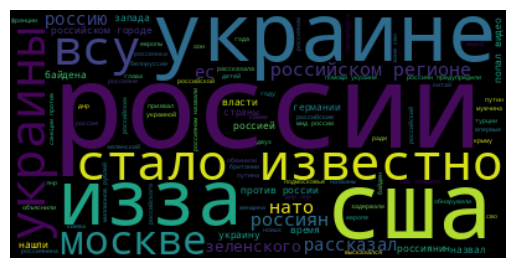

In [136]:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/preprocessed_lenta_titles.csv", encoding="utf-8", sep = ",")

In [ ]:
df.head()

,Unnamed: 0,title,tags,text_lower,text_punct,text_stop,text_common,text_rare,text_nonum,text_token,text_lemm,text_ready
0,0,В Курской области объявили опасность атаки БПЛА,Происшествия,в курской области объявили опасность атаки бпла,в курской области объявили опасность атаки бпла,курской области объявили опасность атаки бпла,курской объявили опасность атаки бпла,курской объявили опасность атаки бпла,курской объявили опасность атаки бпла,"['курской', 'объявили', 'опасность', 'атаки', ...",курский объявить опасность атака бпнуть,курский область объявить опасность атака бпнуть
1,1,Юристы прокомментировали иск пострадавших в от...,Следствие и суд,юристы прокомментировали иск пострадавших в от...,юристы прокомментировали иск пострадавших в от...,юристы прокомментировали иск пострадавших отно...,юристы прокомментировали иск пострадавших отно...,юристы прокомментировали иск пострадавших отно...,юристы прокомментировали иск пострадавших отно...,"['юристы', 'прокомментировали', 'иск', 'постра...",юрист прокомментировать иск пострадать отношен...,юрист прокомментировать иск пострадать отношен...
2,2,На Западе рассказали о нехватке Patriot для пе...,Политика,на западе рассказали о нехватке patriot для пе...,на западе рассказали о нехватке patriot для пе...,западе рассказали нехватке patriot передачи всу,западе нехватке patriot передачи,западе нехватке patriot передачи,западе нехватке patriot передачи,"['западе', 'нехватке', 'patriot', 'передачи']",запад нехватка patriot передача,запад рассказать нехватка patriot передача всу
3,3,Очередные российские спортсмены отказались от ...,Летние виды,очередные российские спортсмены отказались от ...,очередные российские спортсмены отказались от ...,очередные российские спортсмены отказались уча...,очередные спортсмены отказались участия олимпиаде,очередные спортсмены отказались участия олимпиаде,очередные спортсмены отказались участия олимпиаде,"['очередные', 'спортсмены', 'отказались', 'уча...",очередной спортсмен отказаться участие олимпиада,очередной российский спортсмен отказаться учас...
4,4,Байден и Си Цзиньпин обсудили ситуацию вокруг ...,Политика,байден и си цзиньпин обсудили ситуацию вокруг ...,байден и си цзиньпин обсудили ситуацию вокруг ...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,"['байден', 'си', 'цзиньпин', 'обсудили', 'ситу...",байден си цзиньпин обсудить ситуация вокруг ti...,байден си цзиньпин обсудить ситуация вокруг ti...


In [ ]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

In [ ]:
w2v_model = Word2Vec(
    min_count=10,
    window=2,
    vector_size=300,
    negative=10,
    alpha=0.03,
    min_alpha=0.0007,
    sample=6e-5,
    sg=1)

In [ ]:
#Получаем лист слов
from nltk.tokenize import sent_tokenize
from gensim.utils import simple_preprocess
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
class MySentences(object):
    def __init__(self, docs):
        self.corpus = docs
    def __iter__(self):
        for doc in self.corpus:
            doc_sentences = sent_tokenize(doc)
            for sent in doc_sentences:
                yield simple_preprocess(sent) # yields a tokenized

In [ ]:
df['title'].dropna(inplace=True)
sentences = MySentences(df['title'].astype(str).tolist())

In [ ]:
w2v_model.build_vocab(sentences)

In [ ]:
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=6, report_delay=1)

(1478682, 3126552)

In [ ]:
w2v_model.wv.most_similar_to_given("сша", ["россия", "ес"])

'ес'

**bag-of-words**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
count_vectorizer = CountVectorizer()

In [ ]:
texts = df['text_lemm'].astype(str)

In [ ]:
bow = count_vectorizer.fit_transform(texts)
bow.shape

(69001, 23586)

In [ ]:
texts

,text_lemm
0,курский объявить опасность атака бпнуть
1,юрист прокомментировать иск пострадать отношен...
2,запад нехватка patriot передача
3,очередной спортсмен отказаться участие олимпиада
4,байден си цзиньпин обсудить ситуация вокруг ti...
...,...
68996,летний москвич наслать мёртвый одежда свой ком...
68997,изобретательница целебный мастурбация отвергну...
68998,обстрелять донецк рсзый град
68999,сыграть гэндальф актёр пообещать пранкер приех...


In [ ]:
count_vectorizer.vocabulary_

{'курский': 9419,
 'объявить': 12703,
 'опасность': 13023,
 'атака': 1812,
 'бпнуть': 2717,
 'юрист': 23473,
 'прокомментировать': 16338,
 'иск': 7691,
 'пострадать': 15455,
 'отношение': 13459,
 'владелец': 3455,
 'крокус': 9231,
 'запад': 6802,
 'нехватка': 12192,
 'patriot': 689,
 'передача': 14042,
 'очередной': 13673,
 'спортсмен': 19504,
 'отказаться': 13389,
 'участие': 21596,
 'олимпиада': 12945,
 'байден': 1929,
 'си': 18598,
 'цзиньпин': 22370,
 'обсудить': 12654,
 'ситуация': 18688,
 'вокруг': 3672,
 'tiktok': 913,
 'последствие': 15396,
 'мощный': 11015,
 'землетрясение': 7099,
 'тайвань': 20170,
 'показать': 14966,
 'родственник': 17701,
 'погибнуть': 14597,
 'назначить': 11306,
 'пенсия': 13972,
 'цунами': 22415,
 'достигнуть': 5950,
 'японский': 23548,
 'остров': 13300,
 'близ': 2511,
 'ужесточение': 21189,
 'мобилизация': 10813,
 'военный': 3597,
 'закон': 6645,
 'британия': 2768,
 'осудить': 13309,
 'северный': 18393,
 'корея': 8948,
 'пуск': 16671,
 'баллистический': 

**TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
def tokenizer(text):
  return text.split()

In [ ]:
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        preprocessor=None, tokenizer=tokenizer)

In [ ]:
t0 = tfidf.fit_transform(texts)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
tfidf.get_feature_names_out()

array(['aap', 'aasm', 'abl', ..., 'ёлкин', 'ёлочный', 'ёмкость'],
      dtype=object)

In [ ]:
len(tfidf.get_feature_names_out())

23587

In [ ]:
t0[0].toarray()[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
import numpy as np

In [ ]:
result = np.where(t0[0].toarray()[0] > 0)[0]
result.tolist()

[1812, 2717, 9420, 12704, 13024]

In [ ]:
tfidf.get_feature_names_out()[1469]

'альцгеймер'

In [ ]:
for i in result:
  print(tfidf.get_feature_names_out()[i])

атака
бпнуть
курский
объявить
опасность


In [ ]:
t0[0].todense()

matrix([[0., 0., 0., ..., 0., 0., 0.]])

**TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf_vectorizer=TfidfVectorizer(use_idf=True)

In [ ]:
texts = df.title.astype(str)

In [ ]:
texts

,title
0,В Курской области объявили опасность атаки БПЛА
1,Юристы прокомментировали иск пострадавших в от...
2,На Западе рассказали о нехватке Patriot для пе...
3,Очередные российские спортсмены отказались от ...
4,Байден и Си Цзиньпин обсудили ситуацию вокруг ...
...,...
68996,15-летнего москвича нашли мертвым без одежды в...
68997,Изобретательница целебной мастурбации отвергла...
68998,ВСУ обстреляли Донецк из РСЗО «Град»
68999,Сыгравший Гэндальфа актер пообещал пранкерам п...


In [ ]:
tfidf_vectorizer_vectors=tfidf_vectorizer.fit_transform(texts)

In [ ]:
first_vector_tfidfvectorizer=tfidf_vectorizer_vectors[0]

In [ ]:
df1 = pd.DataFrame(first_vector_tfidfvectorizer.T.todense(), index=tfidf_vectorizer.get_feature_names_out(), columns=["tfidf"])
df1.sort_values(by=["tfidf"],ascending=False)

,tfidf
курской,0.490243
бпла,0.431450
опасность,0.419568
объявили,0.394920
атаки,0.377370
...,...
киевской,0.000000
киевском,0.000000
киевскому,0.000000
киевстар,0.000000


**LDA**

In [ ]:
# packages to store and manipulate data
import numpy as np
import pandas as pd
# model building package
import sklearn

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_df=0.95, min_df=2)

[nltk_data] Error loading russian_stopwords: Package
[nltk_data]     'russian_stopwords' not found in index


False

In [ ]:
df['text_lemm'] = df['text_lemm'].astype(str).apply(lambda x: ' '.join([word for word in x.split() if word not in (russian_stopwords)]))

In [ ]:
dtm = cv.fit_transform(df['text_lemm'].astype(str))

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
LDA = LatentDirichletAllocation(n_components=45,random_state=42)

In [ ]:
LDA.fit(dtm)

LatentDirichletAllocation(n_components=45, random_state=42)

In [ ]:
print(len(LDA.components_),type(LDA.components_))

45 <class 'numpy.ndarray'>


In [ ]:
single_topic = LDA.components_[0]
top_10_words = single_topic.argsort()[-10:]

In [ ]:
for index in top_10_words:
    print(cv.get_feature_names_out()[index])

дом
белгород
объявить
атака
житель
погибнуть
пострадать
опасность
обстрел
человек


In [ ]:
for index,topic in enumerate(LDA.components_):
    print(f'THE TOP 15 WORDS FOR TOPIC #{index}')
    print([cv.get_feature_names_out()[i] for i in topic.argsort()[-45:]])
    print('\n')

THE TOP 15 WORDS FOR TOPIC #0
['пять', 'время', 'обрушение', 'около', 'четыре', 'мирный', 'взрыв', 'губернатор', 'авария', 'дтп', 'попасть', 'гибель', 'пляж', 'угрожать', 'улица', 'связь', 'место', 'край', 'появиться', 'бпнуть', 'ил', 'село', 'группа', 'ребёнок', 'крушение', 'сообщить', 'регион', 'жилой', 'белгородский', 'донецк', 'севастополь', 'результат', 'сторона', 'ракетный', 'город', 'дом', 'белгород', 'объявить', 'атака', 'житель', 'погибнуть', 'пострадать', 'опасность', 'обстрел', 'человек']


THE TOP 15 WORDS FOR TOPIC #1
['киев', 'заявить', 'передать', 'перехват', 'россиянин', 'договориться', 'испытать', 'билет', 'подполье', 'himars', 'сообщить', 'сложность', 'задуматься', 'вывоз', 'комплекс', 'польша', 'валюта', 'цена', 'зерно', 'рубеж', 'резкий', 'рекордный', 'торговля', 'массово', 'рсзый', 'объём', 'истребитель', 'дефицит', 'россия', 'поставка', 'час', 'авиакомпания', 'российский', 'выпустить', 'украина', 'снаряд', 'покупка', 'средство', 'производство', 'запустить', 'регио

**Var2**

In [ ]:
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'\w+')

# Векторизация TF-IDF
tfidf = TfidfVectorizer(lowercase=True,
                        ngram_range = (1,1),
                        tokenizer = tokenizer.tokenize)


train_data = tfidf.fit_transform(documents_list)

NameError: name 'documents_list' is not defined

In [ ]:
# Define the number of topics or components
num_components=5

# Create LDA object
model=LatentDirichletAllocation(n_components=num_components)

# Fit and Transform SVD model on data
lda_matrix = model.fit_transform(train_data)

# Get Components
lda_components=model.components_

In [ ]:
terms = tfidf.get_feature_names_out()

for index, component in enumerate(lda_components):
    zipped = zip(terms, component)
    top_terms_key=sorted(zipped, key = lambda t: t[1], reverse=True)[:7]
    top_terms_list=list(dict(top_terms_key).keys())
    print("Topic "+str(index)+": ",top_terms_list)

Topic 0:  ['в', 'сша', 'на', 'с', 'байден', 'к', '19']
Topic 1:  ['в', 'сша', 'и', 'по', 'на', 'с', 'не']
Topic 2:  ['в', 'с', 'и', 'байден', 'на', 'сша', 'россии']
Topic 3:  ['в', 'о', 'сша', 'с', 'на', 'и', 'байден']
Topic 4:  ['в', 'сша', 'с', 'на', 'от', 'и', 'о']
